In [11]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [12]:
import sys
import types
from pathlib import Path

import torch
import pandas as pd

sys.path.append("src")
from entropy_pruning import (
    AttentionForecaster,
    UNILoRAClassifier,
    UNILoRAWithForecasterPruning,
    build_loaders,
    evaluate_classifier,
    set_seed,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [13]:
# ── Shared config ─────────────────────────────────────────────────────────────
PRUNE_LAYER = 2
KEEP_RATIO  = 0.1   # keep 10% of tokens
SEED        = 42

CKPT_ROOT = Path("/raid/DATASETS/checkpoints-Attention-Pruning")

DATASETS = [
    dict(
        name        = "NCT-CRC-HE-100K",
        data_dir    = "/raid/DATASETS/NCT-CRC-HE/",
        classifier  = CKPT_ROOT / "NCT-CRC-HE/uni_finetuned/best_model.pt",
        forecaster  = CKPT_ROOT / "NCT-CRC-HE/forecaster/forecaster_src02_tgt23.pt",
        finetuned   = CKPT_ROOT / "NCT-CRC-HE/pruned_finetuned/best_prune_layer2_keep10.pt",
    ),
    # dict(
    #     name        = "BREAKHIS",
    #     data_dir    = "/raid/DATASETS/BREAKHIS/",
    #     classifier  = CKPT_ROOT / "BREAKHIS/uni_finetuned/best_model.pt",
    #     forecaster  = CKPT_ROOT / "BREAKHIS/forecaster/forecaster_src02_tgt23.pt",
    #     finetuned   = CKPT_ROOT / "BREAKHIS/pruned_finetuned/best_prune_layer2_keep10.pt",
    # ),
]

set_seed(SEED)
print(f"Prune layer: {PRUNE_LAYER}  |  Keep ratio: {KEEP_RATIO*100:.0f}%")
for d in DATASETS:
    print(f"  [{d['name']}]")
    for k, v in d.items():
        if k != 'name' and k != 'data_dir':
            print(f"    {k}: {v}  (exists={Path(v).exists()})")

Prune layer: 2  |  Keep ratio: 10%
  [NCT-CRC-HE-100K]
    classifier: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_finetuned/best_model.pt  (exists=True)
    forecaster: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/forecaster/forecaster_src02_tgt23.pt  (exists=True)
    finetuned: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/pruned_finetuned/best_prune_layer2_keep10.pt  (exists=True)


In [14]:
all_results = []

for ds in DATASETS:
    name = ds["name"]
    print(f"\n{'='*55}")
    print(f"  Dataset: {name}")
    print(f"{'='*55}")

    loaders = build_loaders(
        data_dir=ds["data_dir"],
        img_size=224,
        batch_size=64,
        num_workers=4,
    )
    n_classes = loaders.n_classes
    print(f"  Classes ({n_classes}): {loaders.class_names}")

    # ── load forecaster (shared across conditions 2 & 3) ─────────────────────
    forecaster = AttentionForecaster(embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1).to(device)
    forecaster.load_state_dict(torch.load(ds["forecaster"], map_location=device))
    forecaster.eval()
    for p in forecaster.parameters():
        p.requires_grad_(False)

    # ── 1. Baseline: full classifier, no pruning ──────────────────────────────
    print("\n[1/3] Baseline (no pruning)...")
    baseline = UNILoRAClassifier(n_classes).to(device)
    baseline.load_state_dict(torch.load(ds["classifier"], map_location=device), strict=False)
    m1 = evaluate_classifier(baseline, loaders.test_loader, device)
    print(f"  acc={m1['acc']:.4f}  f1={m1['f1_macro']:.4f}")
    del baseline; torch.cuda.empty_cache()

    # ── 2. Pruning only (forecaster pre-trained, no phase-3 finetuning) ───────
    print("\n[2/3] Pruning only (no phase-3 finetuning)...")
    pruned_only = UNILoRAWithForecasterPruning(
        n_classes=n_classes,
        forecaster=forecaster,
        prune_layer=PRUNE_LAYER,
        keep_ratio=KEEP_RATIO,
    ).to(device)
    pruned_only.load_state_dict(torch.load(ds["classifier"], map_location=device), strict=False)
    m2 = evaluate_classifier(pruned_only, loaders.test_loader, device)
    print(f"  acc={m2['acc']:.4f}  f1={m2['f1_macro']:.4f}")
    del pruned_only; torch.cuda.empty_cache()

    # ── 3. Pruning + phase-3 finetuning ──────────────────────────────────────
    print("\n[3/3] Pruning + finetuned classifier (phase 3)...")
    pruned_ft = UNILoRAWithForecasterPruning(
        n_classes=n_classes,
        forecaster=forecaster,
        prune_layer=PRUNE_LAYER,
        keep_ratio=KEEP_RATIO,
    ).to(device)
    pruned_ft.load_state_dict(torch.load(ds["finetuned"], map_location=device), strict=False)
    m3 = evaluate_classifier(pruned_ft, loaders.test_loader, device)
    print(f"  acc={m3['acc']:.4f}  f1={m3['f1_macro']:.4f}")
    del pruned_ft; torch.cuda.empty_cache()

    row = dict(
        dataset=name,
        keep_pct=int(KEEP_RATIO * 100),
        baseline_acc=m1["acc"],   baseline_f1=m1["f1_macro"],
        pruned_acc=m2["acc"],     pruned_f1=m2["f1_macro"],
        finetuned_acc=m3["acc"],  finetuned_f1=m3["f1_macro"],
        drop_pruned_acc=m2["acc"]      - m1["acc"],
        drop_pruned_f1 =m2["f1_macro"] - m1["f1_macro"],
        drop_finetuned_acc=m3["acc"]      - m1["acc"],
        drop_finetuned_f1 =m3["f1_macro"] - m1["f1_macro"],
    )
    all_results.append(row)

    # ── save per-dataset CSV (always overwrite with latest run) ──────────────
    Path("results").mkdir(exist_ok=True)
    ds_path = Path(f"results/pruning_comparison_{name}.csv")
    pd.DataFrame([row]).to_csv(ds_path, index=False)
    print(f"\n  Saved → {ds_path}")

# ── merge all per-dataset CSVs into the global file ──────────────────────────
existing = []
for p in sorted(Path("results").glob("pruning_comparison_*.csv")):
    existing.append(pd.read_csv(p))

df = pd.concat(existing, ignore_index=True) if existing else pd.DataFrame(all_results)
df.to_csv("results/pruning_comparison.csv", index=False)
print(f"\nGlobal CSV updated → results/pruning_comparison.csv  ({len(df)} rows)")
df


  Dataset: NCT-CRC-HE-100K
  Classes (9): ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']

[1/3] Baseline (no pruning)...
  acc=0.8490  f1=0.7883

[2/3] Pruning only (no phase-3 finetuning)...
  acc=0.5716  f1=0.5397

[3/3] Pruning + finetuned classifier (phase 3)...
  acc=0.9046  f1=0.8723

  Saved → results/pruning_comparison_NCT-CRC-HE-100K.csv

Global CSV updated → results/pruning_comparison.csv  (2 rows)


,dataset,keep_pct,baseline_acc,baseline_f1,pruned_acc,pruned_f1,finetuned_acc,finetuned_f1,drop_pruned_acc,drop_pruned_f1,drop_finetuned_acc,drop_finetuned_f1
0,BREAKHIS,10,0.984341,0.987325,0.851603,0.806507,0.981706,0.984714,-0.132738,-0.180818,-0.002634,-0.002611
1,NCT-CRC-HE-100K,10,0.849025,0.788297,0.571588,0.539726,0.904596,0.872264,-0.277437,-0.248571,0.055571,0.083967


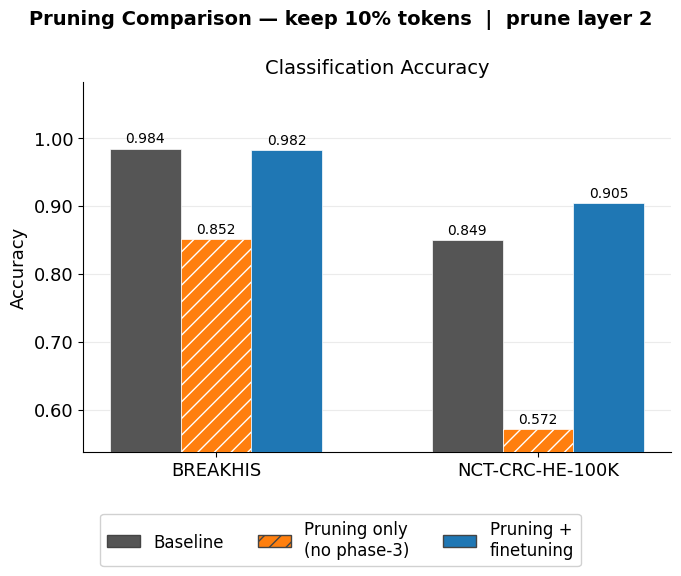

Saved → results/pruning_accuracy.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

df_plot = pd.read_csv("results/pruning_comparison.csv")

FONT = 13
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         FONT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
})

CONDITIONS  = ["Baseline", "Pruning only\n(no phase-3)", "Pruning +\nfinetuning"]
ACC_COLS    = ["baseline_acc", "pruned_acc", "finetuned_acc"]
COLORS      = ["#555555", "#ff7f0e", "#1f77b4"]
HATCHES     = ["", "//", ""]

datasets = df_plot["dataset"].tolist()
n_ds     = len(datasets)
n_cond   = len(CONDITIONS)

x        = np.arange(n_ds)
width    = 0.22
offsets  = np.linspace(-(n_cond-1)/2, (n_cond-1)/2, n_cond) * width

fig, ax = plt.subplots(figsize=(7,5))

fig.suptitle(
    f"Pruning Comparison — keep {df_plot['keep_pct'].iloc[0]}% tokens  |  prune layer {PRUNE_LAYER}",
    fontsize=FONT + 1, fontweight="bold"
)

cols = ACC_COLS

for i, (col, cond, color, hatch) in enumerate(zip(cols, CONDITIONS, COLORS, HATCHES)):
    vals = df_plot[col].values
    bars = ax.bar(
        x + offsets[i], vals, width,
        color=color, hatch=hatch,
        edgecolor="white", linewidth=0.5,
        label=cond, zorder=3,
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=FONT - 3,
        )


ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=FONT)
ax.set_ylabel("Accuracy", fontsize=FONT)
ax.set_title("Classification Accuracy", fontsize=FONT + 1)

ymin = min(df_plot[cols].min()) * 0.94
ymax = max(df_plot[cols].max()) * 1.10
ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", alpha=0.25, zorder=0)

legend_patches = [
    mpatches.Patch(facecolor=c, hatch=h, edgecolor="#444", label=cond)
    for c, h, cond in zip(COLORS, HATCHES, CONDITIONS)
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=n_cond,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=FONT - 1,
    framealpha=0.9,
)

plt.tight_layout()

out = "results/pruning_accuracy.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved → {out}")

In [16]:
print("Summary — effect of each pipeline stage\n")
for _, row in df_plot.iterrows():
    print(f"{row['dataset']}  (keep {row['keep_pct']}% tokens)")
    print(f"  Baseline         acc={row['baseline_acc']:.4f}  f1={row['baseline_f1']:.4f}")
    print(f"  Pruning only     acc={row['pruned_acc']:.4f}  f1={row['pruned_f1']:.4f}  "
          f"(Δacc={row['drop_pruned_acc']:+.4f}  Δf1={row['drop_pruned_f1']:+.4f})")
    print(f"  Pruning+finetune acc={row['finetuned_acc']:.4f}  f1={row['finetuned_f1']:.4f}  "
          f"(Δacc={row['drop_finetuned_acc']:+.4f}  Δf1={row['drop_finetuned_f1']:+.4f})")
    print()

Summary — effect of each pipeline stage

BREAKHIS  (keep 10% tokens)
  Baseline         acc=0.9843  f1=0.9873
  Pruning only     acc=0.8516  f1=0.8065  (Δacc=-0.1327  Δf1=-0.1808)
  Pruning+finetune acc=0.9817  f1=0.9847  (Δacc=-0.0026  Δf1=-0.0026)

NCT-CRC-HE-100K  (keep 10% tokens)
  Baseline         acc=0.8490  f1=0.7883
  Pruning only     acc=0.5716  f1=0.5397  (Δacc=-0.2774  Δf1=-0.2486)
  Pruning+finetune acc=0.9046  f1=0.8723  (Δacc=+0.0556  Δf1=+0.0840)

